# Algortitmo de Deutsche

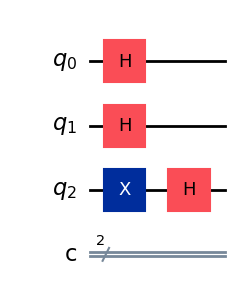

In [53]:
from qiskit import QuantumCircuit

n=2
qc = QuantumCircuit(n+1,n)

for i in range(n):
    qc.h(i)

qc.x(n)
qc.h(n)

qc.draw(output="mpl")


In [54]:
import numpy as np 
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import Aer
from qiskit import transpile


Uf_balanced_0 = np.array([
    [0, 1, 0, 0, 0, 0, 0, 0], 
    [1, 0, 0, 0, 0, 0, 0, 0], 
    [0, 0, 0, 1, 0, 0, 0, 0], 
    [0, 0, 1, 0, 0, 0, 0, 0], 
    [0, 0, 0, 0, 1, 0, 0, 0], 
    [0, 0, 0, 0, 0, 1, 0, 0], 
    [0, 0, 0, 0, 0, 0, 1, 0], 
    [0, 0, 0, 0, 0, 0, 0, 1], 
])

Uf_unbalanced_1 = np.array([
    [0, 1, 0, 0, 0, 0, 0, 0], 
    [1, 0, 0, 0, 0, 0, 0, 0], 
    [0, 0, 0, 1, 0, 0, 0, 0], 
    [0, 0, 1, 0, 0, 0, 0, 0], 
    [0, 0, 0, 0, 0, 1, 0, 0], 
    [0, 0, 0, 0, 1, 0, 0, 0], 
    [0, 0, 0, 0, 0, 0, 0, 1], 
    [0, 0, 0, 0, 0, 0, 1, 0], 
])


gates = [
         UnitaryGate(Uf_balanced_0, label="Uf Balanced"),
         UnitaryGate(Uf_unbalanced_1, label="Uf UnBalanced")
        ]

desc = [
        "balanced"
       ]

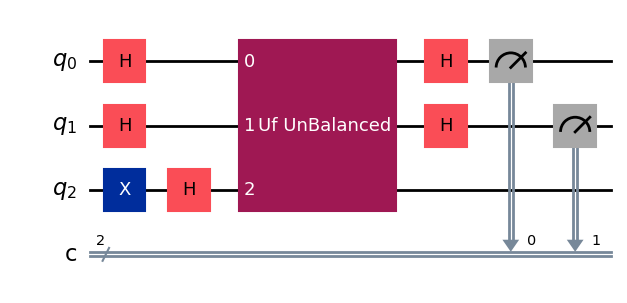

In [ ]:
qc.append(Uf_unbalanced_1, [0,1,2])

for i in range(n):
    qc.h(i)
qc.measure(range(n),range(n))
display(qc.draw(output="mpl"))

In [56]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("qasm_simulator")

job = backend.run(transpile(qc, backend), shots=1024)
result = job.result()


counts = result.get_counts()
print(counts)


{'00': 1024}
